In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import sys
from pyspark.sql import SparkSession
spark = SparkSession.builder \
.master("local") \
.appName("Exercise1") \
.getOrCreate()

In [2]:
df = spark.read.csv("shared/US_Accidents_March23.csv", header=True, inferSchema=True)
#df.show(vertical=True)
df.printSchema()

root
 |-- ID: string (nullable = true)
 |-- Source: string (nullable = true)
 |-- Severity: integer (nullable = true)
 |-- Start_Time: timestamp (nullable = true)
 |-- End_Time: timestamp (nullable = true)
 |-- Start_Lat: double (nullable = true)
 |-- Start_Lng: double (nullable = true)
 |-- End_Lat: double (nullable = true)
 |-- End_Lng: double (nullable = true)
 |-- Distance(mi): double (nullable = true)
 |-- Description: string (nullable = true)
 |-- Street: string (nullable = true)
 |-- City: string (nullable = true)
 |-- County: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Zipcode: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Timezone: string (nullable = true)
 |-- Airport_Code: string (nullable = true)
 |-- Weather_Timestamp: timestamp (nullable = true)
 |-- Temperature(F): double (nullable = true)
 |-- Wind_Chill(F): double (nullable = true)
 |-- Humidity(%): double (nullable = true)
 |-- Pressure(in): double (nullable = true)
 |-- V

In [3]:
from pyspark.sql.functions import month, year, col

# Extract year and month
df_monthly = df.withColumn("year", year(col("Start_Time"))) \
               .withColumn("month", month(col("Start_Time")))

# Group and count
monthly_counts = df_monthly.groupBy("year", "month") \
                          .count() \
                          .orderBy("year", "month")

monthly_counts.show()

+----+-----+-----+
|year|month|count|
+----+-----+-----+
|2016|    1|    7|
|2016|    2|  985|
|2016|    3| 6330|
|2016|    4|18088|
|2016|    5|17610|
|2016|    6|30538|
|2016|    7|45780|
|2016|    8|56457|
|2016|    9|54698|
|2016|   10|55669|
|2016|   11|65040|
|2016|   12|59619|
|2017|    1|55713|
|2017|    2|51679|
|2017|    3|57315|
|2017|    4|48115|
|2017|    5|41136|
|2017|    6|46272|
|2017|    7|43262|
|2017|    8|80955|
+----+-----+-----+
only showing top 20 rows



<Figure size 1200x600 with 0 Axes>

<BarContainer object of 87 artists>

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86],
 [Text(0, 0, '2016-1'),
  Text(1, 0, '2016-2'),
  Text(2, 0, '2016-3'),
  Text(3, 0, '2016-4'),
  Text(4, 0, '2016-5'),
  Text(5, 0, '2016-6'),
  Text(6, 0, '2016-7'),
  Text(7, 0, '2016-8'),
  Text(8, 0, '2016-9'),
  Text(9, 0, '2016-10'),
  Text(10, 0, '2016-11'),
  Text(11, 0, '2016-12'),
  Text(12, 0, '2017-1'),
  Text(13, 0, '2017-2'),
  Text(14, 0, '2017-3'),
  Text(15, 0, '2017-4'),
  Text(16, 0, '2017-5'),
  Text(17, 0, '2017-6'),
  Text(18, 0, '2017-7'),
  Text(19, 0, '2017

Text(0.5, 1.0, 'Monthly Car Accidents')

Text(0.5, 0, 'Year-Month')

Text(0, 0.5, 'Number of Accidents')

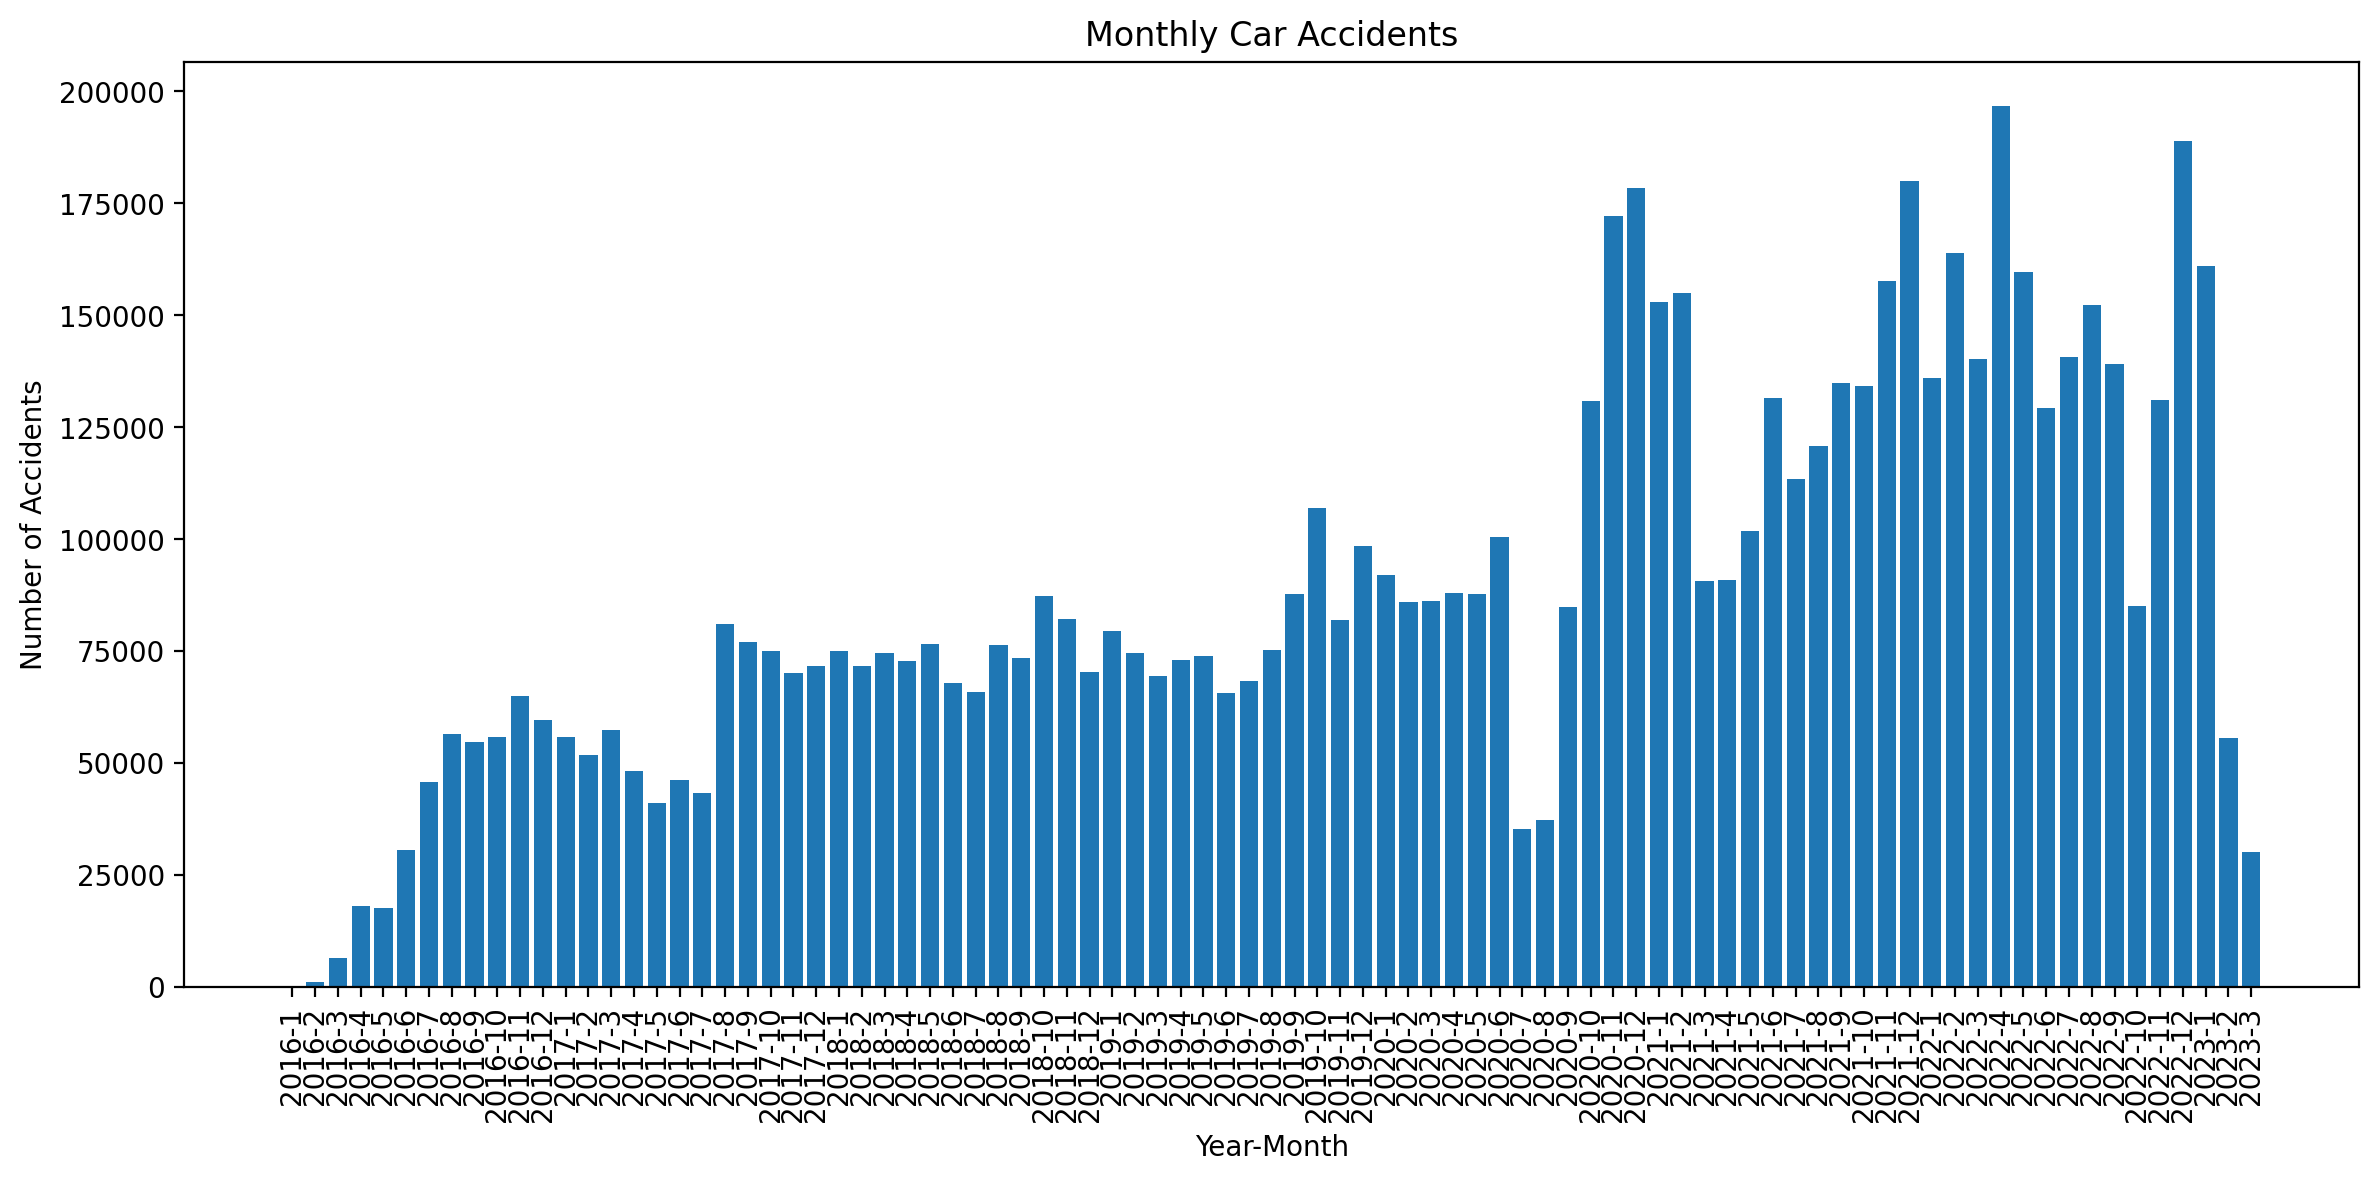

In [4]:
pdf = monthly_counts.toPandas()

import matplotlib.pyplot as plt

pdf["year_month"] = pdf["year"].astype(str) + "-" + pdf["month"].astype(str)

plt.figure(figsize=(12,6))
plt.bar(pdf["year_month"], pdf["count"])
plt.xticks(rotation=90)
plt.title("Monthly Car Accidents")
plt.xlabel("Year-Month")
plt.ylabel("Number of Accidents")
plt.tight_layout()
plt.show()

In [5]:
from pyspark.sql.functions import month, col

monthly_counts = df.withColumn("month", month(col("Start_Time"))) \
                   .groupBy("month") \
                   .count() \
                   .orderBy("month")

monthly_counts.show()

monthly_ranked = monthly_counts.orderBy(col("count").desc())

monthly_ranked.show()

+-----+------+
|month| count|
+-----+------+
|    1|751946|
|    2|658984|
|    3|554595|
|    4|587300|
|    5|558176|
|    6|571373|
|    7|512335|
|    8|599666|
|    9|651381|
|   10|675130|
|   11|760165|
|   12|847343|
+-----+------+

+-----+------+
|month| count|
+-----+------+
|   12|847343|
|   11|760165|
|    1|751946|
|   10|675130|
|    2|658984|
|    9|651381|
|    8|599666|
|    4|587300|
|    6|571373|
|    5|558176|
|    3|554595|
|    7|512335|
+-----+------+



In [6]:
from pyspark.sql.functions import date_format

monthly_counts = df.withColumn("month_name", date_format(col("Start_Time"), "MMMM")) \
                   .withColumn("month", month(col("Start_Time"))) \
                   .groupBy("month", "month_name") \
                   .count() \
                   .orderBy("month")

monthly_ranked = monthly_counts.orderBy(col("count").desc())

monthly_ranked.show()

+-----+----------+------+
|month|month_name| count|
+-----+----------+------+
|   12|  December|847343|
|   11|  November|760165|
|    1|   January|751946|
|   10|   October|675130|
|    2|  February|658984|
|    9| September|651381|
|    8|    August|599666|
|    4|     April|587300|
|    6|      June|571373|
|    5|       May|558176|
|    3|     March|554595|
|    7|      July|512335|
+-----+----------+------+



In [7]:
from pyspark.sql.window import Window
from pyspark.sql.functions import rank

window = Window.orderBy(col("count").desc())

monthly_ranked = monthly_counts.withColumn("rank", rank().over(window))

monthly_ranked.show()

+-----+----------+------+----+
|month|month_name| count|rank|
+-----+----------+------+----+
|   12|  December|847343|   1|
|   11|  November|760165|   2|
|    1|   January|751946|   3|
|   10|   October|675130|   4|
|    2|  February|658984|   5|
|    9| September|651381|   6|
|    8|    August|599666|   7|
|    4|     April|587300|   8|
|    6|      June|571373|   9|
|    5|       May|558176|  10|
|    3|     March|554595|  11|
|    7|      July|512335|  12|
+-----+----------+------+----+



<Figure size 1000x600 with 0 Axes>

<BarContainer object of 12 artists>

Text(0.5, 1.0, 'Car Accidents by Month (All Years Combined)')

Text(0.5, 0, 'Month')

Text(0, 0.5, 'Number of Accidents')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'January'),
  Text(1, 0, 'February'),
  Text(2, 0, 'March'),
  Text(3, 0, 'April'),
  Text(4, 0, 'May'),
  Text(5, 0, 'June'),
  Text(6, 0, 'July'),
  Text(7, 0, 'August'),
  Text(8, 0, 'September'),
  Text(9, 0, 'October'),
  Text(10, 0, 'November'),
  Text(11, 0, 'December')])

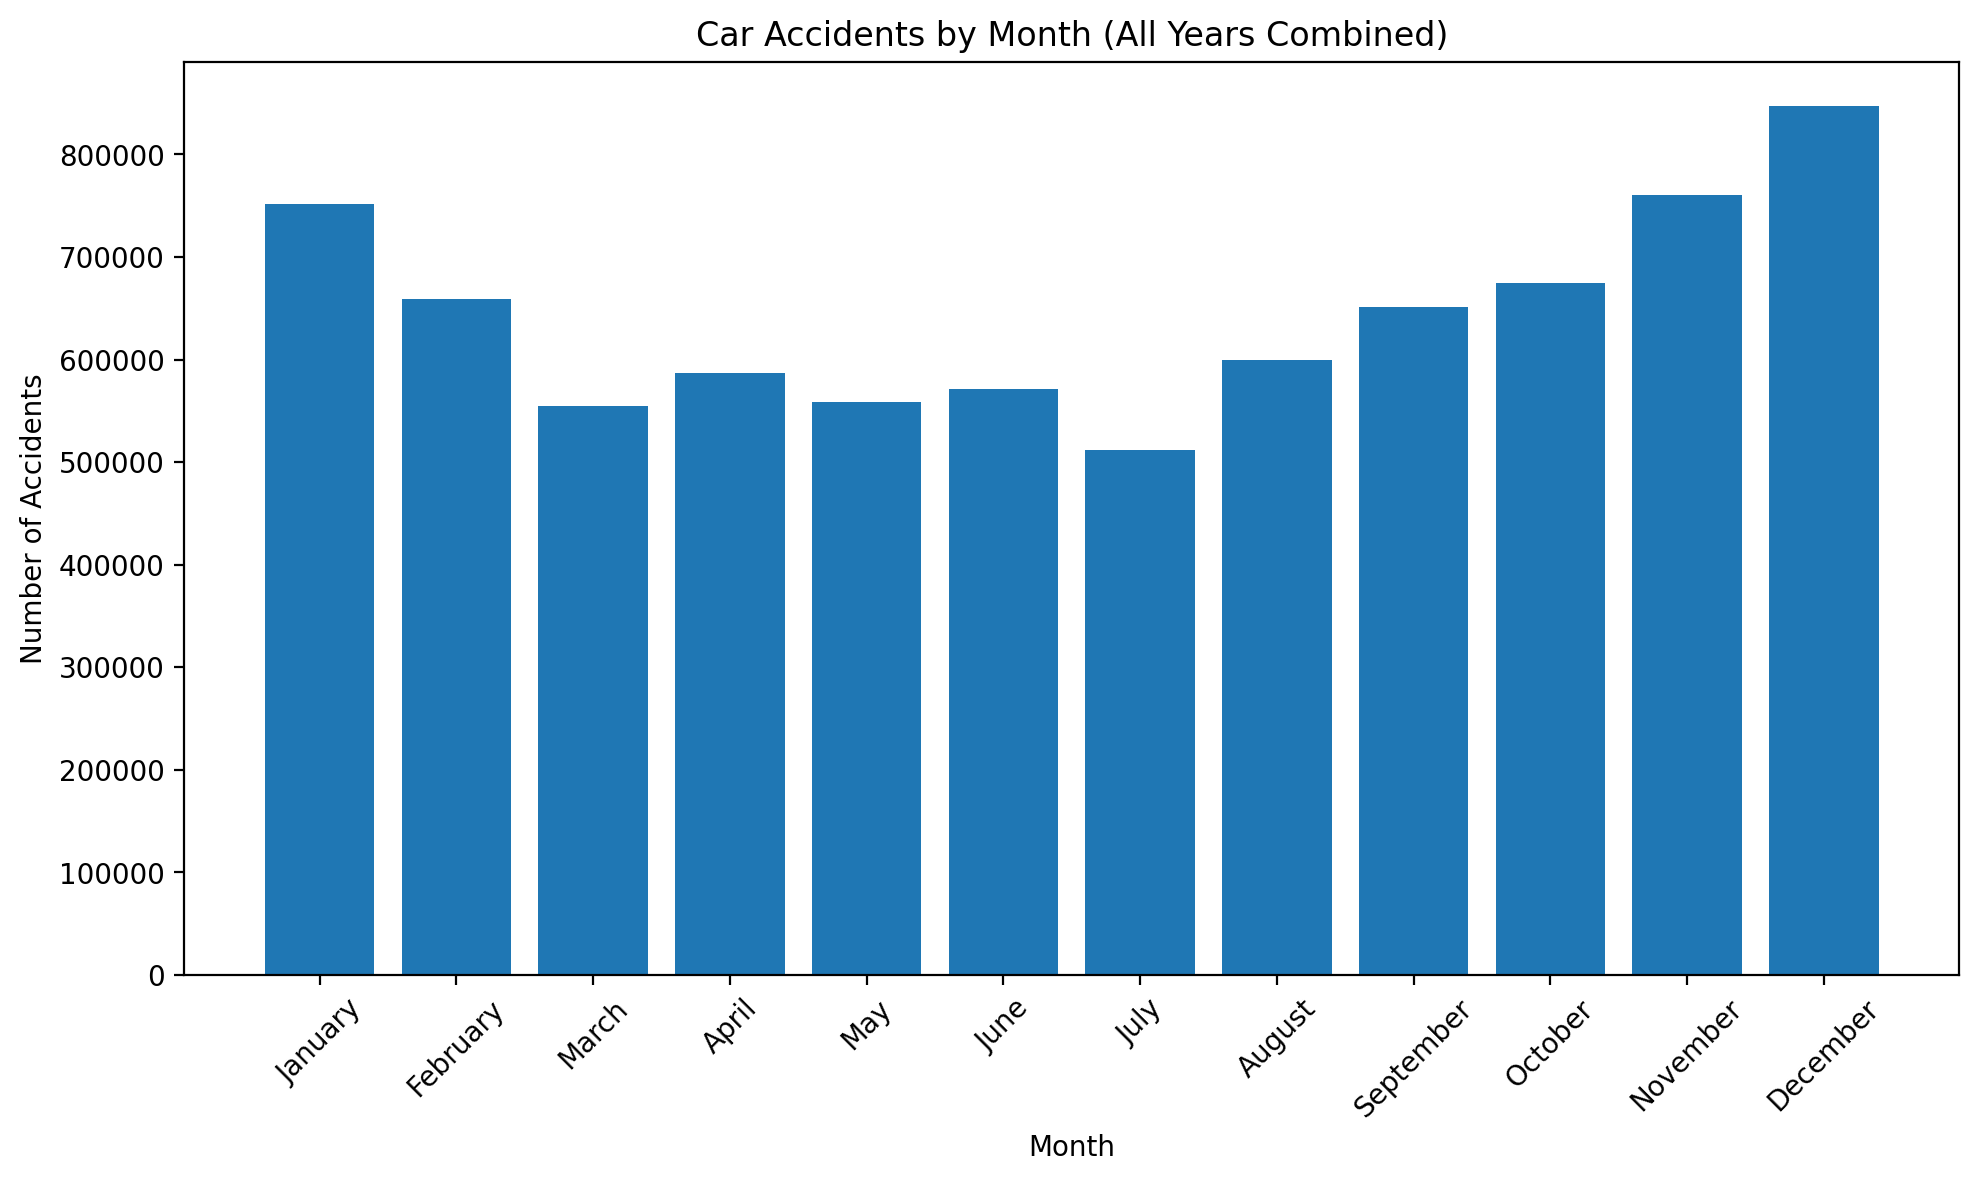

In [8]:
pdf = monthly_ranked.toPandas()
pdf = pdf.sort_values("count", ascending=False)
pdf = pdf.sort_values("month")

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(pdf["month_name"], pdf["count"])

plt.title("Car Accidents by Month (All Years Combined)")
plt.xlabel("Month")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()